# **Preparing Dependancies**

In [1]:
%pip install -q \
torch \
torchvision \
diffusers \
transformers \
accelerate \
safetensors \
xformers \
Pillow \
matplotlib \
numpy \
opencv-python \
streamlit \
streamlit-drawable-canvas \
segment-anything

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline, EulerAncestralDiscreteScheduler, DPMSolverSDEScheduler, DDIMScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [3]:
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    dtype = torch.float16,
    use_safetensors = True,
    safety_checker = None,
)

pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


## **Generate Image**

  0%|          | 0/50 [00:00<?, ?it/s]

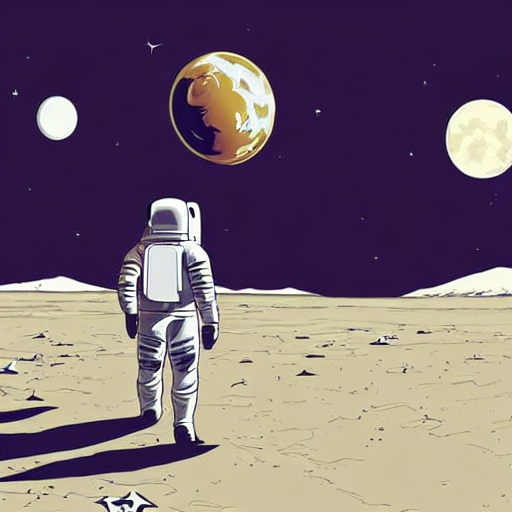

In [53]:
prompt = "astronaut walking on the left side of the moon surface, white spacesuit, black visor, Earth on the right background, black sky filled with tiny stars, wide lunar landscape, stylized cartoon illustration, clean outlines, soft cel shading, vibrant colors, animated adventure style"
image_baseline = pipe(prompt).images[0]
image_baseline

## **Generate Image with Hyperparameter Configuration**

In [54]:
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
seed = 222
generator = torch.Generator("cuda").manual_seed(seed)

  0%|          | 0/50 [00:00<?, ?it/s]

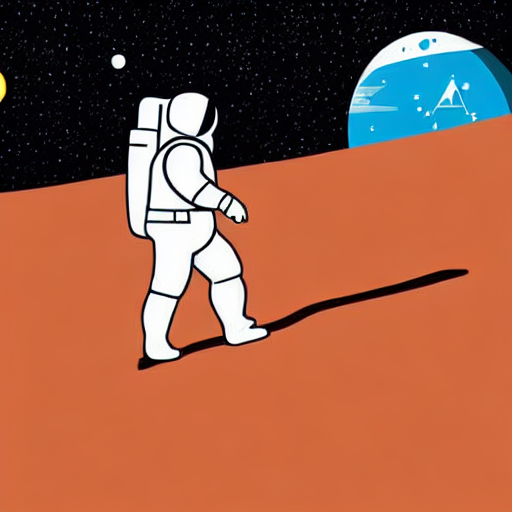

In [55]:
def generate_simple_image():
    image = pipe(
        prompt= prompt,
        negative_prompt= negative_prompt,
        generator=generator,
    ).images[0]
    return image

generate_simple_image()



  0%|          | 0/60 [00:00<?, ?it/s]

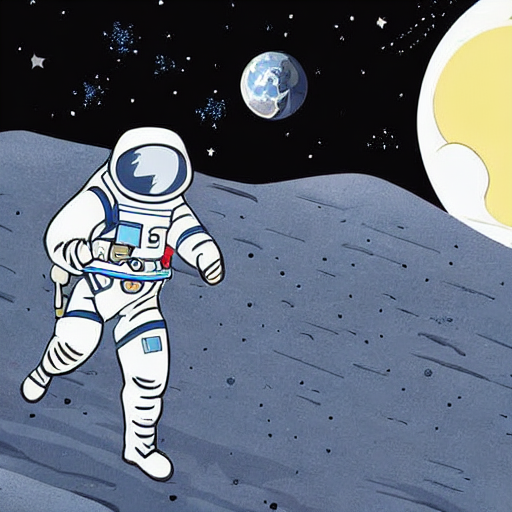

In [56]:
def generate_advanced_image(g_scale, n_step):
    image = pipe(
        prompt= prompt,
        negative_prompt= negative_prompt,
        guidance_scale=g_scale,
        num_inference_steps=n_step,
        generator=generator,
    ).images[0]
    return image
generate_advanced_image(5, 60)

## **Guidance Scale Comparison**

In [57]:
def generate_gscale_image(g_scale):
    image = pipe(
        prompt= prompt,
        negative_prompt= negative_prompt,
        guidance_scale=g_scale,
        generator=generator,
    ).images[0]
    return image

  0%|          | 0/50 [00:00<?, ?it/s]

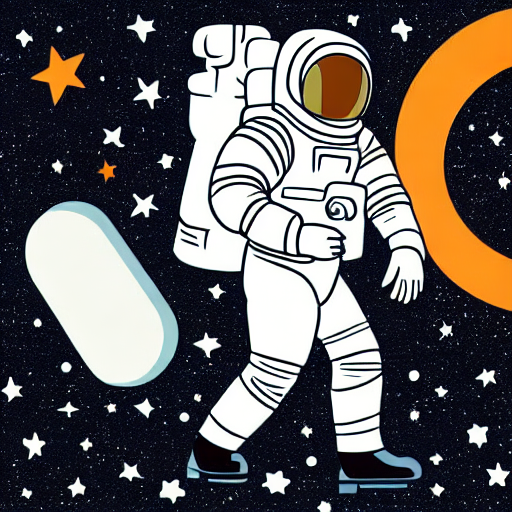

In [58]:
generate_gscale_image(5)

  0%|          | 0/50 [00:00<?, ?it/s]

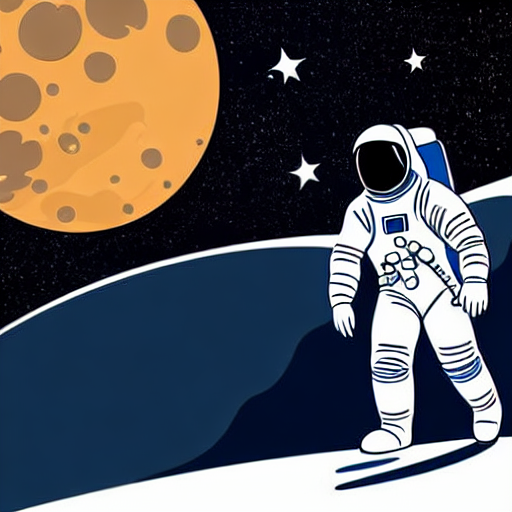

In [59]:
generate_gscale_image(10)

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*Pada Guidance Scale sebesar 5, gambar masih mampu menampilkan objek utama seperti astronot dan bintang sesuai dengan prompt yang diberikan. Namun, beberapa elemen visual belum terbentuk secara optimal dan terdapat bagian yang kurang sesuai dengan deskripsi prompt. Hal ini menunjukkan bahwa nilai Guidance Scale yang rendah memberikan kebebasan lebih besar kepada model dalam menghasilkan gambar, sehingga variasi visual yang dihasilkan cenderung lebih beragam. Karena pengaruh prompt tidak terlalu kuat, tingkat kesesuaian terhadap instruksi teks menjadi lebih rendah dibandingkan Guidance Scale yang lebih tinggi. Pada eksperimen ini, fokus pengujian dilakukan terhadap pengaruh Guidance Scale sehingga parameter inference step dibuat tetap dan tidak menjadi variabel yang dianalisis.*

*   **Gambar dengan "Scale" Tinggi:**   
*Pada Guidance Scale sebesar 10, gambar menunjukkan tingkat kesesuaian yang lebih tinggi terhadap prompt dibandingkan Guidance Scale 5. Objek utama seperti astronot, bulan, dan elemen luar angkasa berhasil ditampilkan dengan lebih jelas. Hal ini menunjukkan bahwa peningkatan Guidance Scale membuat model lebih patuh terhadap instruksi yang diberikan pada prompt. Meskipun demikian, masih terdapat beberapa elemen yang kurang sesuai. Sebagai contoh, muncul objek menyerupai bulan pada bagian kiri atas yang tidak secara eksplisit disebutkan dalam prompt. Selain itu, permukaan bulan yang seharusnya terlihat lebih jelas masih tampak dominan berwarna putih tanpa detail yang cukup. Kondisi ini menunjukkan bahwa meskipun Guidance Scale yang lebih tinggi meningkatkan kesesuaian terhadap prompt, model masih dapat menghasilkan elemen tambahan atau detail yang belum sepenuhnya sesuai dengan deskripsi yang diinginkan. Pada eksperimen ini, parameter inference step dipertahankan pada nilai yang sama untuk seluruh pengujian sehingga perubahan hasil yang diamati difokuskan pada pengaruh Guidance Scale.*

## **Inference Steps Comparison**

In [60]:
def generate_step_image(n_step):
    image = pipe(
        prompt= prompt,
        negative_prompt= negative_prompt,
        num_inference_steps=n_step,
        generator=generator,
    ).images[0]
    return image

  0%|          | 0/20 [00:00<?, ?it/s]

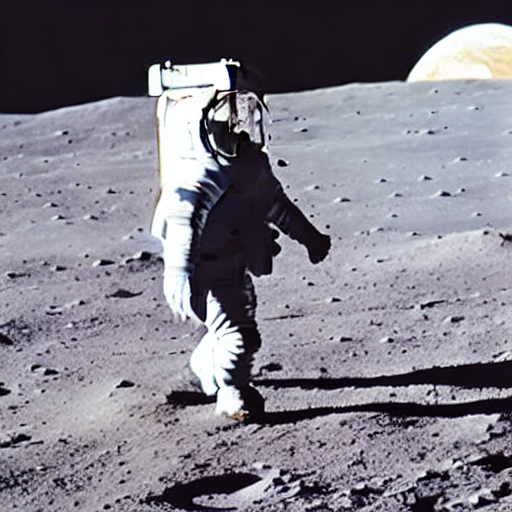

In [62]:
generate_step_image(20)

  0%|          | 0/40 [00:00<?, ?it/s]

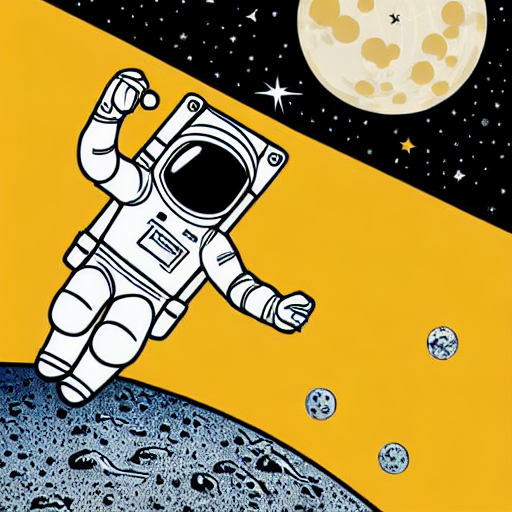

In [63]:
generate_step_image(40)


### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*Pada inference step 20, objek astronot masih sesuai dengan deskripsi prompt yang diberikan. Karakteristik utama seperti keberadaan astronot dan komposisi ruang angkasa masih dapat dikenali. Namun, terdapat beberapa ketidaksempurnaan, seperti bagian kepala astronot yang kurang jelas serta elemen bumi yang tidak berhasil terbentuk sesuai instruksi prompt. Hal ini menunjukkan bahwa proses denoising belum mampu menghasilkan seluruh detail yang diinginkan secara optimal.*
*   **Gambar dengan "Step" Tinggi:**  
*Pada inference step 40, kualitas visual gambar terlihat lebih halus dan bersih, tetapi kesesuaian terhadap prompt justru menurun. Astronot tampak berada dalam posisi melayang yang berbeda dari deskripsi awal, muncul area berwarna kuning pada latar belakang yang tidak disebutkan dalam prompt, serta elemen bumi tidak terlihat pada hasil akhir. Kondisi ini menunjukkan bahwa peningkatan jumlah inference step tidak selalu menghasilkan kesesuaian prompt yang lebih baik pada setiap generasi gambar.*

## **Batch Inference from One Prompt**

## **Load Scheduler**

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

## **Inpainting**

### **Load Model Inpainting**

### **Manual Masking**

### **Generate**

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

### **Masking with Segmentation Model**

### **Generate**

## **Outpainting**

### **Prepare the Canvas**

### **Generate**

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

### **Generate**